# Задача 2

Используя методы дихотомии, простых итераций и Ньютона, найти уровень энергии $ E $  основного состояния квантовой частицы в прямоугольной потенциальной яме:

$$
-\frac{1}{2}\psi''(x)+U(x)\psi(x)=E\psi(x), \quad U(x)=
\begin{cases}
-U_0, & |x|\leq a,\\
0, & |x|>a.
\end{cases}
$$

---

## Получение уравнения для энергии.

### Волновая функция основного состояния:

Для связанного состояния $-U_0<E<0$. Введём обозначения:

$$
    k=\sqrt{2(E+U_0)}, \qquad \kappa=\sqrt{-2E}.
$$

Внутри ямы уравнение Шрёдингера принимает вид $\psi''+k^2\psi=0$,
а вне ямы — $\psi''-\kappa^2\psi=0$.

Основное состояние симметричной ямы является чётным и не имеет узлов.
Поэтому выбираем косинус внутри ямы и убывающую экспоненту снаружи:

$$
    \psi(x)=
    \begin{cases}
        A\cos(kx), & |x|\leq a,\\
        B e^{-\kappa(|x|-a)}, & |x|>a.
    \end{cases}
$$

На границе $x=a$ волновая функция и её производная непрерывны:

$$
    \begin{cases}
        A\cos(ka)=B,\\
        -Ak\sin(ka)=-\kappa B.
    \end{cases}
    \quad\Rightarrow\quad
    k\tan(ka)=\kappa.
$$

На границе $x=-a$ те же условия выполняются благодаря чётности.
Получаем уравнение для энергии:

$$
    \sqrt{2(E+U_0)}\tan\!\left(a\sqrt{2(E+U_0)}\right)=\sqrt{-2E}.
$$

### Переход к безразмерной переменной:

Положим

$$
    z=ka, \qquad \rho=a\sqrt{2U_0}.
$$

Тогда

$$
    z\tan z=\sqrt{\rho^2-z^2}.
$$

Для основного состояния $0<z<\pi/2$, поскольку внутри ямы не должно
быть нулей косинуса. Также $z<\rho$, так как $E<0$.
На этом интервале обе части положительны, поэтому можно возвести
уравнение в квадрат:

$$
    z^2\tan^2z=\rho^2-z^2
    \quad\Rightarrow\quad
    \frac{z^2}{\cos^2z}=\rho^2
    \quad\Rightarrow\quad
    z=\rho\cos z.
$$

Будем искать корень функции

$$
    f(z)=z-\rho\cos z, \qquad 0<z<b, \qquad
    b=\min\left(\rho,\frac{\pi}{2}\right).
$$

Имеем $f(0)=-\rho<0$, $f(b)>0$ и $f'(z)=1+\rho\sin z\geq1$.
Следовательно, на этом интервале есть ровно один корень.

После его нахождения вычислим энергию:

$$
    E=\frac{z^2}{2a^2}-U_0=-U_0\sin^2z.
$$

Последнее равенство выполняется в корне, поскольку $z=\rho\cos z$.
В коде используем его, чтобы при малой глубине ямы не вычитать близкие числа.

### Задание параметров:

В условии численные значения $U_0$ и $a$ не указаны.
Для примера возьмём $U_0=1$, $a=1$. Их можно изменить в следующей ячейке
и затем выполнить все ячейки ниже.

Точность по безразмерному корню зададим как $\varepsilon=10^{-12}$.
Так как $f'(z)\geq1$, из теоремы о среднем следует

$$
    |z-z_*|\leq |f(z)|,
$$

где $z_*$ — точный корень. Поэтому для всех трёх методов используем
одинаковое условие остановки $|f(z)|\leq\varepsilon$.
При этом ошибка энергии, вычисленной по $-U_0\sin^2z$,
не превосходит $U_0\varepsilon$ без учёта округления.

In [4]:
import numpy as np

U0 = 10.0
a = 1.0
eps = 1e-12

rho = a * np.sqrt(2.0 * U0)
b = min(rho, np.pi / 2.0)


def f(z):
    return z - rho * np.cos(z)


def df(z):
    return 1.0 + rho * np.sin(z)


def find_energy(z):
    return -U0 * np.sin(z)**2

## Рисунок корня.

Построим функцию вида:

$$
    z \tan (z ) = \sqrt{\rho ^2 - z ^2} 
$$ 

зададим $ \rho=10$. 


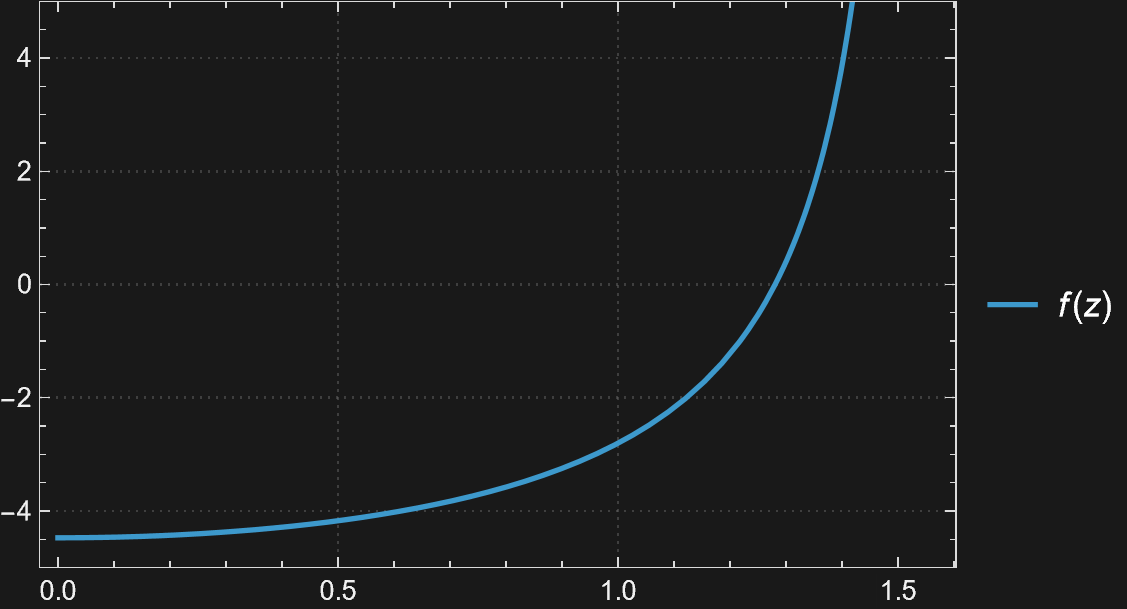

In [5]:
%%wl

a=1.0;
U0=10.0;
rho = a Sqrt[2 U0];

f[z_] := z Tan[z] - Sqrt[rho^2 - z^2];

Plot[f[z], {z, 0, Pi/2},
 PlotRange -> {-5, 5},
 PlotTheme -> "Detailed"]


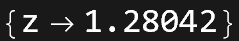

In [6]:
%%wl
FindRoot[f[z] == 0, {z, 1}]

## Метод дихотомии.

Берём отрезок $[0,b]$, на концах которого функция имеет разные знаки.
На каждом шаге находим середину:

$$
    z=\frac{z_{\mathrm{left}}+z_{\mathrm{right}}}{2}.
$$

Если $f(z)<0$, корень лежит справа — заменяем левую границу на $z$.
Если $f(z)>0$, заменяем правую границу.
Так на каждом шаге длина отрезка уменьшается вдвое.

In [7]:
def find_dichotomy(eps=1e-12, max_iter=10000):

    left = 0.0
    right = b

    for n in range(1, max_iter + 1):
        z = (left + right) / 2.0
        value = f(z)

        if abs(value) <= eps:
            return z, n

        if value < 0:
            left = z
        else:
            right = z

    raise RuntimeError("Метод дихотомии не достиг заданной точности")

In [16]:
z_dichotomy, n_dichotomy = find_dichotomy(eps)
E_dichotomy = find_energy(z_dichotomy)

print(f"z = {z_dichotomy}")
print(f"E = {E_dichotomy}")
print(f"Количество итераций: {n_dichotomy}")

z = 1.2804218631111626
E = -9.180259926232928
Количество итераций: 42


## Метод простых итераций.

Прямой переход $z_{n+1}=\rho\cos z_n$ не всегда даёт сходимость:
модуль производной $|\rho\sin z|$ может быть больше единицы.
Воспользуемся постоянным корректирующим множителем, как в лекции:

$$
    z_{n+1}=\varphi(z_n)=z_n-\lambda f(z_n), \qquad
    \lambda=\frac{1}{1+\rho}.
$$

Проверим условие сходимости на $[0,b]$:

$$
    \varphi'(z)=1-\frac{1+\rho\sin z}{1+\rho}
    =\frac{\rho(1-\sin z)}{1+\rho},
    \qquad
    0\leq\varphi'(z)\leq\frac{\rho}{1+\rho}<1.
$$

Функция $\varphi$ возрастает, $\varphi(0)>0$ и $\varphi(b)<b$,
поэтому итерации остаются внутри отрезка и сходятся к его единственному корню.
Начальное приближение возьмём $z_0=b$.

In [9]:
def find_iterations(eps=1e-12, max_iter=10000):

    z = b
    lam = 1.0 / (1.0 + rho)

    for n in range(1, max_iter + 1):
        z_next = z - lam * f(z)

        if abs(f(z_next)) <= eps:
            return z_next, n

        z = z_next

    raise RuntimeError("Метод простых итераций не достиг заданной точности")

In [10]:
z_iterations, n_iterations = find_iterations(eps)
E_iterations = find_energy(z_iterations)

print(f"z = {z_iterations}")
print(f"E = {E_iterations}")
print(f"Количество итераций: {n_iterations}")

z = 1.2804218631114224
E = -9.180259926234354
Количество итераций: 8


## Метод Ньютона.

Используем формулу:

$$
    z_{n+1}=z_n-\frac{f(z_n)}{f'(z_n)}
    =z_n-\frac{z_n-\rho\cos z_n}{1+\rho\sin z_n}.
$$

Берём $z_0=b$. На выбранном отрезке $f'(z)>0$ и
$f''(z)=\rho\cos z\geq0$, то есть функция возрастает и выпукла.
Поскольку $f(b)>0$, касательные дают приближения справа от корня,
которые последовательно к нему приближаются.

In [11]:
def find_newton(eps=1e-12, max_iter=10000):

    z = b

    for n in range(1, max_iter + 1):
        z_next = z - f(z) / df(z)

        if abs(f(z_next)) <= eps:
            return z_next, n

        z = z_next

    raise RuntimeError("Метод Ньютона не достиг заданной точности")

In [15]:
z_newton, n_newton = find_newton(eps)
E_newton = find_energy(z_newton)

print(f"z = {z_newton}")
print(f"E = {E_newton}")
print(f"Количество итераций: {n_newton}")

z = 1.2804218631112423
E = -9.180259926233367
Количество итераций: 4


## Сравнение результатов.

Сравним энергии, число итераций и невязку $|f(z)|$ при одной и той же
заданной точности.

In [13]:
results = [
    ("Дихотомия", z_dichotomy, E_dichotomy, n_dichotomy),
    ("Простые итерации", z_iterations, E_iterations, n_iterations),
    ("Ньютон", z_newton, E_newton, n_newton),
]

print(f"{'Метод':<20} {'E':>17} {'Итерации':>10} {'|f(z)|':>14}")

for name, z, energy, n in results:
    print(f"{name:<20} {energy:>17.12f} {n:>10} {abs(f(z)):>14.3e}")

Метод                                E   Итерации         |f(z)|
Дихотомия              -9.180259926233         42      4.217e-13
Простые итерации       -9.180259926234          8      9.515e-13
Ньютон                 -9.180259926233          4      2.220e-16


### Проверка исходного уравнения:

Подставим найденную методом Ньютона энергию в условие сшивки
$k\tan(ka)=\kappa$ и проверим, что $-U_0<E<0$.

In [14]:
k = np.sqrt(2.0 * (E_newton + U0))
kappa = np.sqrt(-2.0 * E_newton)

print(f"k tan(ka) = {k * np.tan(k * a):.12f}")
print(f"kappa     = {kappa:.12f}")
print(f"Невязка исходного уравнения: {abs(k * np.tan(k * a) - kappa):.3e}")
print(f"Энергия лежит между -U0 и 0: {-U0 < E_newton < 0}")

k tan(ka) = 4.284917718284
kappa     = 4.284917718284
Невязка исходного уравнения: 1.243e-14
Энергия лежит между -U0 и 0: True


### Ответ:

Для произвольных $U_0>0$ и $a>0$ энергия основного состояния равна

$$
    \boxed{E_0=-U_0\sin^2z_*}, \qquad
    z_*=a\sqrt{2U_0}\cos z_*, \qquad
    0<z_*<\min\left(a\sqrt{2U_0},\frac{\pi}{2}\right).
$$

Все три метода находят один и тот же уровень энергии с заданной точностью.
Дихотомия на каждом шаге вдвое сужает отрезок, а простые итерации
уменьшают ошибку с коэффициентом, определяемым $\varphi'(z)$.
Метод Ньютона вблизи корня имеет квадратичную сходимость и в данном
примере требует меньше всего итераций.

Число итераций не равно времени работы: на шаге Ньютона дополнительно
вычисляется производная.